In [1]:
import pandas as pd 
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset analyse and feature engineering

In [2]:
df = pd.read_csv(r"datasets\cab_rides.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  str    
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  str    
 4   source            693071 non-null  str    
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  str    
 8   product_id        693071 non-null  str    
 9   name              693071 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 116.7 MB


In [4]:
df.isna().sum()

distance                0
cab_type                0
time_stamp              0
destination             0
source                  0
price               55095
surge_multiplier        0
id                      0
product_id              0
name                    0
dtype: int64

In [5]:
df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [6]:
df.drop(columns=['id','product_id'])

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,Lyft XL
...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,UberXL
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,UberX
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,Taxi
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,Black SUV


In [7]:
df['datetime'] = pd.to_datetime(df['time_stamp'], unit='ms')
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [8]:
df = df.drop(columns=['time_stamp', 'datetime'])

In [9]:
df = pd.get_dummies(df, columns=['cab_type', 'destination', 'source', 'name'], drop_first=True)

In [10]:
corr = df.corr(numeric_only = True)

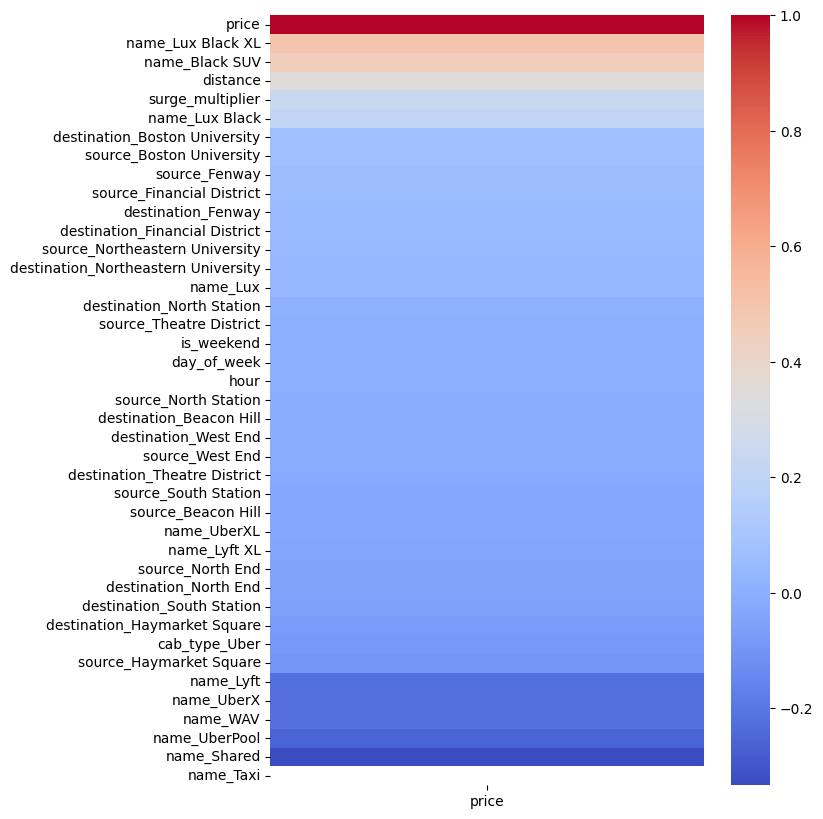

In [11]:
plt.figure(figsize=(7,10))
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False), cmap='coolwarm', fmt='.2f')
plt.show()

In [12]:
corr[['price']].sort_values(by='price', ascending=False).head(5)

,price
price,1.000000
name_Lux Black XL,0.500057
name_Black SUV,0.453096
distance,0.345061
surge_multiplier,0.240458


In [13]:
df = df.dropna(subset=['price'])

In [14]:
treshold = 0.2
low_corr = corr['price'][corr['price'].abs() < treshold].index.tolist()

In [15]:
df = df.drop(columns=[c for c in low_corr if c in df.columns])

In [16]:
corr_matrix = df.drop(columns='price').corr(numeric_only=True)

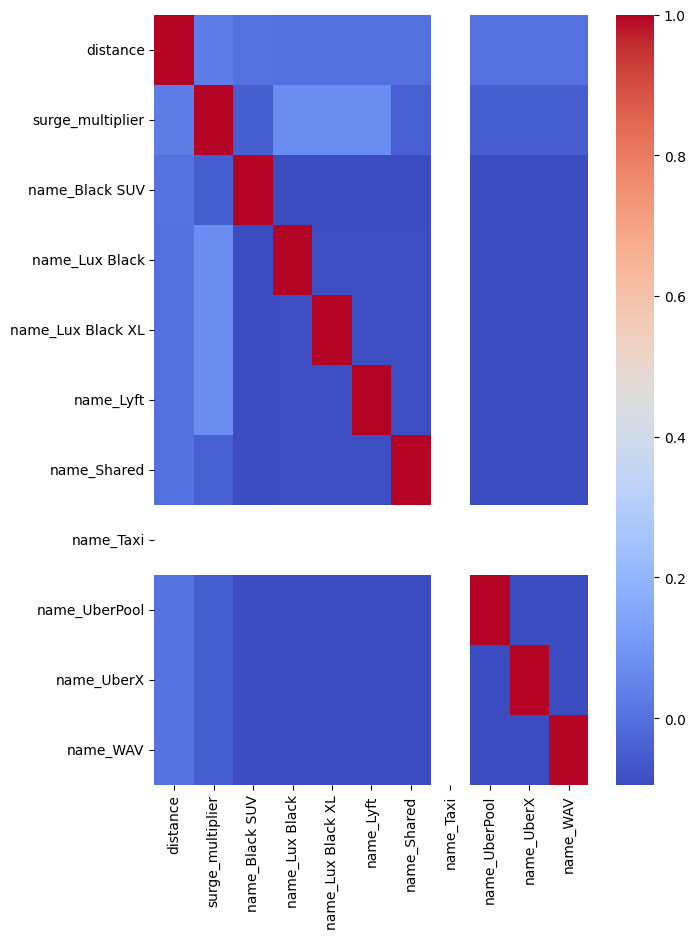

In [17]:
plt.figure(figsize=(7,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f')
plt.show()

In [18]:
df['name_Taxi'].nunique()

1

In [19]:
df = df.drop(columns=['name_Taxi'])